# PD Business Impact – Book Stats, RoE & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, return on equity (RoE), and threshold sensitivity. Compares **baseline (approve all)** vs **model at optimal threshold**.

This notebook has **two parts**, each with the same business-impact focus but different data and models:

| Part | Notebook | What you get |
|------|----------|--------------|
| **I – Home Credit** | `00_pd_homecredit_lstm_kaggle.ipynb` | Business impact from the triple-stream LSTM run: metrics that drive approval/CoR/RoE and threshold choices (from `metrics_summary.json` and 00’s OOT setup). |
| **II – LendingClub** | `02a_pd_xgboost_training.ipynb` (+ `01`) | Full book stats and RoE on OOT test: trained model (`pd_model_local_v2.pkl`), test set from `lendingclub_engineered.parquet` (with `loan_amnt`, `int_rate`, `term_months`). Run 01 and 02a first. |

**Assumption – Cost of funds:** We use **cost_of_funds = 3.0%** as a reasonable assumption for the cost at which the bank funds the loans (e.g. wholesale funding). This is documented here and used in RoE calculations (Part II). Change the constant in code if your environment uses a different rate.

## Part I – Home Credit: Business impact 

`00_pd_homecredit_lstm_kaggle.ipynb`<br>
**Purpose:** Demonstrate business impact of the trained PD model (triple-stream LSTM) using the OOT run from notebook 00: metrics that inform **approval/charge-off rates, RoE, and threshold sensitivity** (LSTM vs baseline). Same context as Part II; inputs come from 00’s pipeline.

**Inputs (from pipeline):** Notebook 00 saves `metrics_summary.json` (and optionally test predictions) after training — on Kaggle under `/kaggle/working/`, locally in repo root or `notebooks/` depending on where you ran the save cell. Copy that JSON to one of the paths below (or set `HOMECREDIT_METRICS_JSON`) so this demo can load it. For full segment-level OOT tables and book stats in 00’s data schema, run the business-impact sections in notebook 00 directly.

**Context:** Data = Kaggle Home Credit Default Risk; model = triple-stream LSTM vs LR/LightGBM (static only); OOT via `SK_ID_CURR`; segments = has_bureau / no_bureau, repayment-bureau (see 00 for methodology).

---

Loaded: c:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\notebooks\metrics_summary.json



,value
lstm_auc,0.916667
lstm_ks,0.833333
lstm_gini,0.833333
precision,0.250000
recall,1.000000
f1,0.400000
baseline_auc,0.500000
baseline_ks,0.000000
epochs_trained,7.000000



List-valued keys (length): {'best_val_auc_by_epoch': 7}


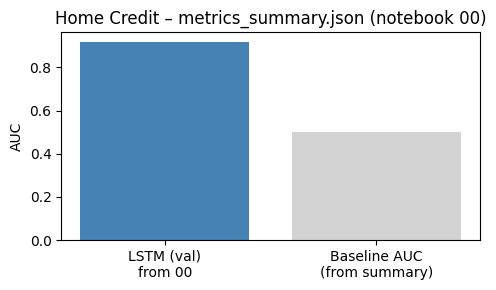

In [1]:
import json
import os
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    display = print

# Optional: full path to JSON from notebook 00 (e.g. /kaggle/working/metrics_summary.json)
HOMECREDIT_METRICS_JSON = os.environ.get("HOMECREDIT_METRICS_JSON", "").strip() or None

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent

candidates = []
if HOMECREDIT_METRICS_JSON:
    candidates.append(Path(HOMECREDIT_METRICS_JSON))
candidates += [
    ROOT / "data" / "home_credit" / "metrics_summary.json",
    ROOT / "notebooks" / "home_credit_metrics_summary.json",
    ROOT / "notebooks" / "metrics_summary.json",
    ROOT / "metrics_summary.json",
]

metrics_path = next((p for p in candidates if p.is_file()), None)
if metrics_path is None:
    print("No metrics_summary.json found. After running 00_pd_homecredit_lstm_kaggle.ipynb, either:")
    print("  • Copy the saved JSON to data/home_credit/metrics_summary.json, or")
    print("  • notebooks/home_credit_metrics_summary.json (recommended name), or")
    print("  • Set env HOMECREDIT_METRICS_JSON=/path/to/metrics_summary.json")
else:
    with open(metrics_path, encoding="utf-8") as f:
        raw = json.load(f)
    scalars = {k: v for k, v in raw.items() if not isinstance(v, (list, dict))}
    lists = {k: len(v) for k, v in raw.items() if isinstance(v, list)}
    print(f"Loaded: {metrics_path}\n")
    if scalars:
        import pandas as pd
        display(pd.DataFrame([scalars]).T.rename(columns={0: "value"}))
    else:
        print(json.dumps(raw, indent=2)[:3000])
    if lists:
        print("\nList-valued keys (length):", lists)
    import matplotlib.pyplot as plt
    if "lstm_auc" in raw and "baseline_auc" in raw:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(["LSTM (val)\nfrom 00", "Baseline AUC\n(from summary)"], [raw["lstm_auc"], raw["baseline_auc"]], color=["steelblue", "lightgray"])
        ax.set_ylabel("AUC")
        ax.set_title("Home Credit – metrics_summary.json (notebook 00)")
        plt.tight_layout()
        plt.show()

## Part I – Business impact (book stats, RoE, threshold sensitivity)

To mirror Part II, this section computes the same business-impact views **if you provide OOT predictions** from notebook 00.

### Required artifact (one file)

Export a small table for the OOT split with at least:

- `pd` (predicted probability of default)
- `y_true` (0/1 default)

Optional (improves realism): `loan_amnt`, `int_rate` (as %), `term_months`.

Save it as CSV or Parquet and point `HOMECREDIT_OOT_PRED_PATH` to it (env var), or place it at one of the default paths used below.

### Economic assumptions (used only when optional fields are missing)

- `COST_OF_FUNDS = 3.0%` (same as Part II)
- `ASSUMED_INT_RATE = 12.0%`
- `ASSUMED_TERM_MONTHS = 36`
- `LGD = 100%` (charge-off equals principal for defaults)

---

In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

COST_OF_FUNDS = 3.0
ASSUMED_INT_RATE = 12.0
ASSUMED_TERM_MONTHS = 36
LGD = 1.0

# Provide this (recommended): CSV/Parquet with columns pd, y_true, and optional loan_amnt/int_rate/term_months
HOMECREDIT_OOT_PRED_PATH = os.environ.get("HOMECREDIT_OOT_PRED_PATH", "").strip() or None

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent

pred_candidates = []
if HOMECREDIT_OOT_PRED_PATH:
    pred_candidates.append(Path(HOMECREDIT_OOT_PRED_PATH))
pred_candidates += [
    ROOT / "data" / "home_credit" / "homecredit_oot_predictions.parquet",
    ROOT / "data" / "home_credit" / "homecredit_oot_predictions.csv",
    ROOT / "notebooks" / "homecredit_oot_predictions.parquet",
    ROOT / "notebooks" / "homecredit_oot_predictions.csv",
]

pred_path = next((p for p in pred_candidates if p.is_file()), None)
if pred_path is None:
    print("No Home Credit OOT prediction file found.")
    print("Create one from 00_pd_homecredit_lstm_kaggle.ipynb (OOT split) with columns: pd, y_true, and optionally loan_amnt/int_rate/term_months.")
    print("Then set env HOMECREDIT_OOT_PRED_PATH=/path/to/file OR save as one of:")
    for p in pred_candidates[1:]:
        print(f"  - {p}")
else:
    if pred_path.suffix.lower() in (".parquet", ".pq"):
        dfp = pd.read_parquet(pred_path)
    else:
        dfp = pd.read_csv(pred_path)

    # normalize column names
    cols = {c.lower(): c for c in dfp.columns}
    pd_col = cols.get("pd") or cols.get("p") or cols.get("p_pred") or cols.get("pred")
    y_col = cols.get("y_true") or cols.get("y") or cols.get("label") or cols.get("default")
    if pd_col is None or y_col is None:
        raise ValueError(f"Prediction file must include pd and y_true columns. Found: {list(dfp.columns)}")

    dfp = dfp.rename(columns={pd_col: "pd", y_col: "y_true"})
    dfp["pd"] = pd.to_numeric(dfp["pd"], errors="coerce")
    dfp["y_true"] = pd.to_numeric(dfp["y_true"], errors="coerce").astype(int)
    dfp = dfp.dropna(subset=["pd", "y_true"]).reset_index(drop=True)

    # Optional economics fields
    if "loan_amnt" not in dfp.columns:
        dfp["loan_amnt"] = 1.0  # unit exposure
    if "int_rate" not in dfp.columns:
        dfp["int_rate"] = ASSUMED_INT_RATE
    if "term_months" not in dfp.columns:
        dfp["term_months"] = ASSUMED_TERM_MONTHS

    dfp["loan_amnt"] = pd.to_numeric(dfp["loan_amnt"], errors="coerce").fillna(1.0)
    dfp["int_rate"] = pd.to_numeric(dfp["int_rate"], errors="coerce").fillna(ASSUMED_INT_RATE)
    dfp["term_months"] = pd.to_numeric(dfp["term_months"], errors="coerce").fillna(ASSUMED_TERM_MONTHS)

    print(f"Loaded Home Credit OOT predictions: {pred_path} (n={len(dfp):,})")

    def book_stats_generic(dfp: pd.DataFrame, threshold: float, label: str):
        # approve if PD < threshold
        approved = dfp["pd"].to_numpy() < threshold
        amnt = dfp.loc[approved, "loan_amnt"].sum()
        charge_off = dfp.loc[approved & (dfp["y_true"] == 1), "loan_amnt"].sum() * LGD
        n_total = len(dfp)
        n_app = int(approved.sum())
        approval_rate = n_app / n_total if n_total else 0.0
        CoR = charge_off / amnt if amnt else 0.0

        app = dfp.loc[approved]
        wgt_int_rate = (app["int_rate"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0
        wgt_term = (app["term_months"] * app["loan_amnt"]).sum() / amnt if amnt else 0.0

        interest_earned = amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
        interest_paid = amnt * (COST_OF_FUNDS / 100.0) * (wgt_term / 12.0)
        banking_profit = interest_earned - interest_paid - charge_off
        RoE = (banking_profit / amnt * 100.0) if amnt else 0.0

        print(f"[{label}] Approval rate: {approval_rate:.2%} | CoR: {CoR:.2%} | RoE: {RoE:.2f}% | Wgt int rate: {wgt_int_rate:.2f}% | Wgt term (mo): {wgt_term:.1f}")
        return {
            "approved_amnt": float(amnt),
            "charged_off_amnt": float(charge_off),
            "approval_rate": float(approval_rate),
            "CoR": float(CoR),
            "RoE": float(RoE),
            "wgt_int_rate": float(wgt_int_rate),
            "wgt_term": float(wgt_term),
            "n_approved": int(n_app),
        }

    # Baseline: approve all
    baseline = book_stats_generic(dfp, threshold=1.0, label="Baseline (approve all)")

    # Choose "optimal" threshold on this OOT file by maximising F1 (same spirit as Part II)
    thresholds = np.arange(0.05, 0.95, 0.05)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (dfp["pd"].to_numpy() >= t).astype(int)
        f1 = f1_score(dfp["y_true"].to_numpy(), y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    print(f"\nChosen threshold (max F1 on provided OOT file): {best_t:.2f} (F1={best_f1:.4f})\n")

    model = book_stats_generic(dfp, threshold=best_t, label=f"Model (threshold={best_t:.2f})")

    # Threshold sensitivity
    rows = []
    for t in thresholds:
        stats = book_stats_generic(dfp, threshold=float(t), label=f"t={t:.2f}")
        rows.append({"threshold": float(t), **{k: stats[k] for k in ("approval_rate", "CoR", "RoE")}})
    sens = pd.DataFrame(rows)

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(sens["threshold"], sens["RoE"], marker="o", color="tab:green", label="RoE (%)")
    ax1.set_xlabel("Threshold (approve if PD < threshold)")
    ax1.set_ylabel("RoE (%)", color="tab:green")
    ax1.tick_params(axis="y", labelcolor="tab:green")
    ax1.axvline(x=best_t, color="gray", linestyle="--", label=f"Chosen = {best_t:.2f}")

    ax2 = ax1.twinx()
    ax2.plot(sens["threshold"], sens["CoR"] * 100.0, marker="s", color="tab:red", label="CoR (%)")
    ax2.set_ylabel("CoR (%)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title("Home Credit – RoE and Charge-off Rate vs Approval Threshold")
    plt.tight_layout()
    plt.show()

---

## Part II – LendingClub: PD Business Impact – Book Stats, RoE & Threshold Sensitivity

**Purpose:** Demonstrate business impact of the trained PD model using out-of-time test set: approval/charge-off rates, return on equity (RoE), and threshold sensitivity. Compares **baseline (approve all)** vs **model at optimal threshold**.

**Inputs (from pipeline):** Trained model (`pd_model_local_v2.pkl`), test set from `lendingclub_engineered.parquet` (with `loan_amnt`, `int_rate`, `term_months` for business metrics). Run **01** and **02a** first so the parquet includes `loan_amnt` and `int_rate` (01 saves them for this demo).

**Assumption – Cost of funds:** We use **cost_of_funds = 3.0%** as a reasonable assumption for the cost at which the bank funds the loans (e.g. wholesale funding). This is documented here and used in RoE calculations. Change the constant in code if your environment uses a different rate.

### Part II – 1. Load trained model and test set

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if not (ROOT / "credit_risk").is_dir():
    raise RuntimeError("Run this notebook from the repo root or notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
MODEL_PATH = ROOT / "models" / "pd" / "pd_model_local_v2.pkl"
if not DATA_PATH.exists():
    raise FileNotFoundError("Run 01_pd_lendingclub_feature_engineering.ipynb first.")
if not MODEL_PATH.exists():
    raise FileNotFoundError("Run 02a_pd_xgboost_training.ipynb and save the model first.")

df = pd.read_parquet(DATA_PATH)
for col in ["loan_amnt", "int_rate"]:
    if col not in df.columns:
        raise ValueError(f"Parquet missing '{col}'. Re-run 01 to add loan_amnt and int_rate for the demo.")

all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
y = df["default"]
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]

test_idx = df["split"] == "test"
X_test = X[test_idx]
y_test = y[test_idx]
df_test = df[test_idx].copy()

# Feature screening (same as 02a): use train to get selected features
train_idx = df["split"] == "train"
X_train = X[train_idx]
y_train = y[train_idx]
screening = screen_features_train_only(X_train, y_train, missingness_threshold=0.50, min_ks=0.001, corr_threshold=0.95)
feature_names = screening.selected_features
X_test_filled = X_test[feature_names].copy()
medians = X_train[feature_names].median()
X_test_filled = X_test_filled.fillna(medians)

model_data = joblib.load(MODEL_PATH)
final_model = model_data["model"]
best_threshold_opt = float(model_data.get("best_threshold", 0.5))
p_test = final_model.predict_proba(X_test_filled)[:, 1]

# Business df: loan_amnt, int_rate, term (months)
term_col = "term_months" if "term_months" in df_test.columns else "term"
if term_col not in df_test.columns:
    raise ValueError("Parquet missing term_months/term. Re-run 01.")
loans_df = df_test[["loan_amnt", "int_rate", term_col]].rename(columns={term_col: "term"})
if loans_df["term"].dtype == object:
    loans_df["term"] = pd.to_numeric(loans_df["term"].astype(str).str.replace(r" months?", "", regex=True), errors="coerce")
loans_df = loans_df.astype(float, errors="ignore")

n_test = len(y_test)
print(f"Test set: {n_test:,} loans. Optimal threshold (from model pkl): {best_threshold_opt:.3f}")

Test set: 21,721 loans. Optimal threshold (from model pkl): 0.500


### Part II – 2. Book stats and RoE helpers

In [3]:
def book_stats(loans_df, p_prob, threshold, label, y_true):
    """Approved = loans where p_prob < threshold (predicted non-default). CoR = charged-off amount / approved amount."""
    y_true = np.asarray(y_true).ravel()
    approved_mask = (np.asarray(p_prob).ravel() < threshold)
    approved_amnt = loans_df.iloc[approved_mask]["loan_amnt"].sum()
    charged_off_amnt = loans_df.iloc[approved_mask & (y_true == 1)]["loan_amnt"].sum()
    n_approved = approved_mask.sum()
    n_total = len(loans_df)
    approval_rate = n_approved / n_total if n_total else 0
    CoR = charged_off_amnt / approved_amnt if approved_amnt else 0
    app = loans_df.iloc[approved_mask]
    wgt_int = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    wgt_term = (app["term"] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0
    print(f"[{label}] Approval rate: {approval_rate:.2%} | CoR: {CoR:.2%} | Weighted avg int rate: {wgt_int_rate:.2f}% | Weighted avg term (mo): {wgt_term:.1f}")
    return {
        "approved_amnt": approved_amnt,
        "charged_off_amnt": charged_off_amnt,
        "approval_rate": approval_rate,
        "CoR": CoR,
        "wgt_int_rate": wgt_int_rate,
        "wgt_term": wgt_term,
        "n_approved": n_approved,
    }

In [4]:
def return_on_equity(approved_amnt, charge_off_amnt, wgt_int_rate, wgt_term, cost_of_funds=3.0):
    """RoE = (interest_earned - interest_paid - charge_off) / approved. All $ in millions for print."""
    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (cost_of_funds / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    RoE_pct = (banking_profit / approved_amnt * 100) if approved_amnt else 0
    scale = 1e6
    print(f"  Interest earned ($m): {interest_earned/scale:.2f} | Interest paid ($m): {interest_paid/scale:.2f} | Charge-off ($m): {charge_off_amnt/scale:.2f}")
    print(f"  Banking profit ($m): {banking_profit/scale:.2f} | RoE: {RoE_pct:.2f}%")
    return RoE_pct

### Part II – 3. Baseline book stats (approve all – no model)

Baseline = approve every loan (threshold 1.0, so all applications are "approved").

In [5]:
COST_OF_FUNDS = 3.0  # % (documented assumption)
# Baseline: approve all (threshold=1.0 so p_test < 1.0 for every loan)
baseline_stats = book_stats(loans_df, p_test, threshold=1.0, label="Baseline (approve all)", y_true=y_test.values)
return_on_equity(
    baseline_stats["approved_amnt"],
    baseline_stats["charged_off_amnt"],
    baseline_stats["wgt_int_rate"],
    baseline_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)

[Baseline (approve all)] Approval rate: 100.00% | CoR: 16.57% | Weighted avg int rate: 13.22% | Weighted avg term (mo): 47.8
  Interest earned ($m): 137.90 | Interest paid ($m): 31.28 | Charge-off ($m): 43.36
  Banking profit ($m): 63.26 | RoE: 24.17%


np.float64(24.173158633911676)

### Part II – 4. Model book stats at optimal threshold

In [6]:
model_stats = book_stats(loans_df, p_test, threshold=best_threshold_opt, label=f"Model (threshold={best_threshold_opt:.2f})", y_true=y_test.values)
return_on_equity(
    model_stats["approved_amnt"],
    model_stats["charged_off_amnt"],
    model_stats["wgt_int_rate"],
    model_stats["wgt_term"],
    cost_of_funds=COST_OF_FUNDS,
)

[Model (threshold=0.50)] Approval rate: 93.09% | CoR: 15.38% | Weighted avg int rate: 12.97% | Weighted avg term (mo): 47.4
  Interest earned ($m): 123.09 | Interest paid ($m): 28.47 | Charge-off ($m): 36.92
  Banking profit ($m): 57.70 | RoE: 24.03%


np.float64(24.026736823755435)

### Part II – 5. Threshold sensitivity analysis

Sweep threshold from 0.2 to 0.8 (step 0.05). For each: approval rate, CoR, RoE, AUC-ROC, F1, recall (TPR), precision. Dual-axis chart: RoE and CoR vs threshold; optimal threshold marked.

In [7]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

thresholds = np.arange(0.2, 0.85, 0.05)
auc_roc = roc_auc_score(y_test, p_test)
y_vals = np.asarray(y_test).ravel()
rows = []
for t in thresholds:
    approved_mask = (p_test < t)
    app = loans_df.iloc[approved_mask]
    approved_amnt = app["loan_amnt"].sum()
    charged_off_amnt = loans_df.iloc[approved_mask & (y_vals == 1)]["loan_amnt"].sum()
    n_approved = approved_mask.sum()
    approval_rate = n_approved / len(y_test)
    CoR = charged_off_amnt / approved_amnt if approved_amnt else 0
    wgt_int = (app["int_rate"] * app["loan_amnt"]).sum()
    wgt_int_rate = wgt_int / approved_amnt if approved_amnt else 0
    wgt_term = (app["term"] * app["loan_amnt"]).sum() / approved_amnt if approved_amnt else 0
    interest_earned = approved_amnt * (wgt_int_rate / 100) * (wgt_term / 12)
    interest_paid = approved_amnt * (COST_OF_FUNDS / 100) * (wgt_term / 12)
    banking_profit = interest_earned - interest_paid - charged_off_amnt
    RoE = (banking_profit / approved_amnt * 100) if approved_amnt else 0
    y_pred = (p_test >= t).astype(int)
    rows.append({
        "threshold": t,
        "approval_rate": approval_rate,
        "CoR": CoR,
        "RoE": RoE,
        "AUC_ROC": auc_roc,
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
    })
sens_df = pd.DataFrame(rows)
print("Metrics by threshold:")
print(sens_df.round(4).to_string())
sens_df

Metrics by threshold:
    threshold  approval_rate     CoR      RoE  AUC_ROC      F1  recall  precision
0        0.20         0.7951  0.1373  23.6079   0.6361  0.2762  0.3245     0.2404
1        0.25         0.8293  0.1407  23.8121   0.6361  0.2610  0.2772     0.2465
2        0.30         0.8563  0.1434  23.9247   0.6361  0.2477  0.2411     0.2547
3        0.35         0.8788  0.1458  23.9822   0.6361  0.2310  0.2078     0.2602
4        0.40         0.8983  0.1494  23.9772   0.6361  0.2085  0.1741     0.2598
5        0.45         0.9158  0.1516  23.9948   0.6361  0.1912  0.1486     0.2681
6        0.50         0.9309  0.1538  24.0267   0.6361  0.1709  0.1244     0.2732
7        0.55         0.9434  0.1552  24.0823   0.6361  0.1537  0.1056     0.2829
8        0.60         0.9555  0.1567  24.0988   0.6361  0.1346  0.0870     0.2968
9        0.65         0.9654  0.1579  24.1663   0.6361  0.1161  0.0713     0.3129
10       0.70         0.9747  0.1598  24.1699   0.6361  0.0931  0.0543     0

,threshold,approval_rate,CoR,RoE,AUC_ROC,F1,recall,precision
0,0.20,0.795083,0.137309,23.607900,0.636074,0.276200,0.324537,0.240395
1,0.25,0.829290,0.140668,23.812092,0.636074,0.260956,0.277222,0.246494
2,0.30,0.856314,0.143420,23.924728,0.636074,0.247741,0.241128,0.254726
3,0.35,0.878781,0.145849,23.982166,0.636074,0.231029,0.207765,0.260160
4,0.40,0.898301,0.149430,23.977153,0.636074,0.208500,0.174098,0.259846
5,0.45,0.915842,0.151596,23.994820,0.636074,0.191220,0.148620,0.268053
6,0.50,0.930896,0.153762,24.026737,0.636074,0.170905,0.124355,0.273151
7,0.55,0.943373,0.155165,24.082340,0.636074,0.153744,0.105551,0.282927
8,0.60,0.955481,0.156721,24.098795,0.636074,0.134615,0.087049,0.296794
9,0.65,0.965425,0.157891,24.166254,0.636074,0.116107,0.071277,0.312916


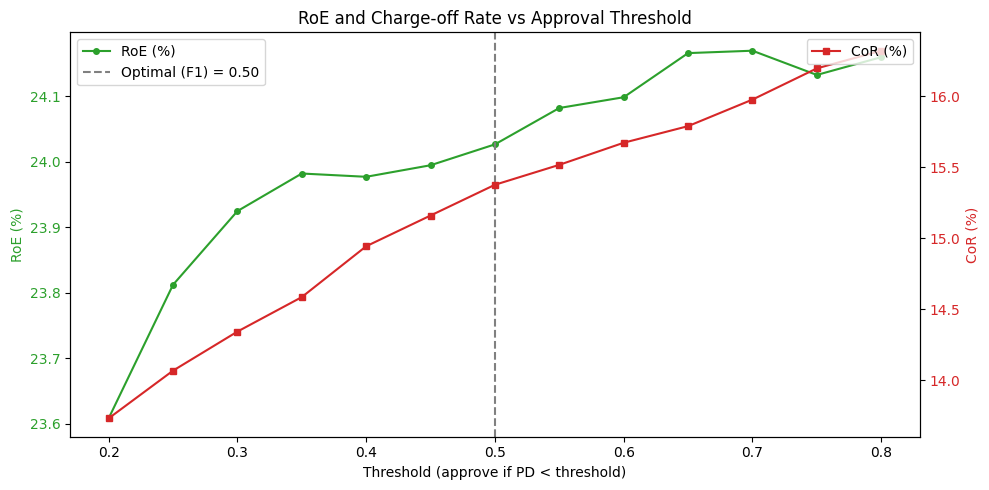

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sens_df["threshold"], sens_df["RoE"], color="tab:green", marker="o", markersize=4, label="RoE (%)")
ax1.set_xlabel("Threshold (approve if PD < threshold)")
ax1.set_ylabel("RoE (%)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")
ax1.axvline(x=best_threshold_opt, color="gray", linestyle="--", label=f"Optimal (F1) = {best_threshold_opt:.2f}")

ax2 = ax1.twinx()
ax2.plot(sens_df["threshold"], sens_df["CoR"] * 100, color="tab:red", marker="s", markersize=4, label="CoR (%)")
ax2.set_ylabel("CoR (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("RoE and Charge-off Rate vs Approval Threshold")
plt.tight_layout()
plt.show()

### Part II – 6. Baseline vs model – business case ($)

Compare $ approved (baseline vs model), $ charge-offs saved, and RoE improvement in percentage points.

In [9]:
def _roe_pct_from_stats(stats: dict, cost_of_funds: float) -> float:
    approved_amnt = float(stats.get("approved_amnt", 0.0))
    if approved_amnt <= 0:
        return 0.0

    wgt_int_rate = float(stats.get("wgt_int_rate", 0.0))
    wgt_term = float(stats.get("wgt_term", 0.0))
    charge_off_amnt = float(stats.get("charged_off_amnt", 0.0))

    interest_earned = approved_amnt * (wgt_int_rate / 100.0) * (wgt_term / 12.0)
    interest_paid = approved_amnt * (cost_of_funds / 100.0) * (wgt_term / 12.0)
    banking_profit = interest_earned - interest_paid - charge_off_amnt
    return (banking_profit / approved_amnt) * 100.0

roe_baseline_pct = _roe_pct_from_stats(baseline_stats, COST_OF_FUNDS)
roe_model_pct = _roe_pct_from_stats(model_stats, COST_OF_FUNDS)

approved_baseline = float(baseline_stats["approved_amnt"])
approved_model = float(model_stats["approved_amnt"])
charged_off_baseline = float(baseline_stats["charged_off_amnt"])
charged_off_model = float(model_stats["charged_off_amnt"])
saved_charge_off = charged_off_baseline - charged_off_model
roe_improvement_pp = roe_model_pct - roe_baseline_pct

print("Business case (test cohort)")
print(f"  $ Loans approved – Baseline: ${approved_baseline/1e6:.2f}m  |  Model: ${approved_model/1e6:.2f}m")
print(f"  $ Charge-offs saved (vs baseline): ${saved_charge_off/1e6:.2f}m")
print(f"  RoE – Baseline: {roe_baseline_pct:.2f}%  |  Model: {roe_model_pct:.2f}%  |  Improvement: {roe_improvement_pp:+.2f} pp")


SyntaxError: invalid syntax. Perhaps you forgot a comma? (1046922087.py, line 1)

### Part II – 7. Summary (LendingClub)

*Run the cell below to print a one-paragraph summary with the key numbers from this run.*

In [ ]:
summary = (
    f"At threshold {best_threshold_opt:.2f}, the model approves {model_stats['approval_rate']:.0%} of applications, "
    f"reducing CoR from {baseline_stats['CoR']:.1%} (baseline) to {model_stats['CoR']:.1%}, "
    f"improving portfolio RoE from {roe_baseline_pct:.1f}% to {roe_model_pct:.1f}%, "
    f"saving approximately ${saved_charge_off/1e6:.1f}m in charge-offs on the test cohort."
)
print(summary)